# Introduction

This project aims to analyze prices and locations of Airbnbs using Airbnb data of Chicago, as well as other data sources about Chicago, mainly crime data. The following 12 suggested questions from the instructions should give an introduction to our project (in addition to the report):

1. **Which dataset(s) did you choose? Why?** <br>
   We used essentially three types of data:
   - Airbnb *listings data* (each row is an Airbnb with a number of attributes including geographic information via longitude and latitude values).
   - *Crime data* (each row is a crime incident with a number of attributes, including geographic information via longitude and latitude values).
   - Chicago city data (labeled as "*population data*"; it contains geographic data of Chicago as GeoPandas polygons, including population data. This data serves as a common ground for merging Airbnb and crime data).

2. **How did you clean/transform the data? Why?** <br>
   Thankfully, most of the data was already quite "clean." The main challenge was obtaining the correct geospheric projection of longitude-latitude pairs. In order to make meaningful joins of the data, they all need to be transformed to a common projection (we used this one: [https://epsg.io/26916](https://epsg.io/26916)). Also, in the listings data, one Airbnb was listed with a price of $9999999, which we had to get rid of for obvious reasons. Afterward, we only did variable selection and filtering of rows for the EDA and modeling steps.

3. **How did you solve the problem of missing values? Why?** <br>
   There were barely any missing values, which we dropped. We didn't think this would impact the analyses as it was much less than 1%.

4. **What questions did you ask of the data?**
   - Q1: Can we analyze and predict the locations of Airbnbs within Chicago? <br>
   - Q2: What are the influencing factors behind Airbnb prices, and can we model this meaningfully? <br>

5. **Why were these good questions?**
   - Relevance: Addresses a practical concern in the Airbnb market—location prediction and understanding price determinants are crucial for stakeholders.
   - Applicability: They provide insights for users, hosts, and policymakers in the Airbnb ecosystem.
   - Complexity: Many factors, such as crime rates, population data, and competition, making the study comprehensive.
   - Practical Impact: Outcomes could have practical implications for users looking to book Airbnbs, hosts setting prices, and authorities planning urban development.

6. **What were the answers to these questions?**
   - **ad (q1)** While we were able to analyze the average prices per grid cell (left plot), we discovered a high density of Airbnbs in the north of the map. However, this observation is only partially useful as an explanatory variable, as higher density in Airbnbs also results in higher competition and thus self-regulation in the prices. Conversely, we observed that the density of homicides is much higher in the southwest of Chicago. This, however, is one of the top 10 most relevant features, as we discovered in our combined model.
   - **ad (q2)** The analysis aims to predict Airbnb prices using different combinations of features. Three sets of features (10, 15, and 20) were evaluated with the Random Forest, Linear Regression, and XGBRegressor models. The results reveal an improvement in performance with an increasing number of features, especially with 20 features. The Random Forest model outperforms the others, showing a net with a positive r2_score, suggesting a better fit to the data. Potential reasons for these findings could include the inherent complexity of relationships between Airbnb location features and price. Adding more features may have allowed the models, particularly Random Forest, to better capture the variability in the data. However, this can also lead to overfitting to the training data, hence the need for validation on independent test datasets. Alternatively, the models' moderate performance may be explained by the essentially complex and dynamic nature of the Airbnb rental market, where many factors can influence prices and more likely models are needed to capture these nuances. Parameter adjustments, deeper exploration of features, and use of advanced techniques could also help improve Airbnb price prediction.

7. **How did you obtain them?**
   - **ad (q1)** was basically obtained by the visualizations we created.
   - **ad (q2)** has more "proof" as we have performance measures for our models.

8. **Do the answers make sense?**
   - Overall, most of the results were expected but actually, the **unimportance** of some features surprised us (e.g., the amount of people is not that relevant for predicting the price).

9. **Were there any difficulties in analyzing the data? What were the key insights obtained?**
   - One major problem was the size of the initial crime dataset. 
   - The amenity column was a string of a list like "[]" and hat to be unpacked and then pivoted to a dummy dataframe to be analyzed properly. 
   - Price had to be converted to float (was string before with $ sign)
   
   As for key insights: 
   
   ● Higher Airbnb density in the north, but competition is a problem. 
   
   ● Homicide density is a good predictor of prices. 
   
   ● Random Forest model outperformed others in price prediction.

10. **What are potential biases in the data and analysis?**
    - We only tested our model for the city of Chicago and did not apply it to other cities, so we are not sure how well it generalizes. However, this would have extended the scope of this assignment a fair bit, so we accepted this Closed Classification World Assumption.

11. **Which Data Science tools and techniques were learned during this exercise?**
    - Associate Rule Learning, Geocoder, Uszipcode, K-Means-Clustering

12. **How was the work divided up between the members of the group?**
    - Overall, everyone was involved in all main processes (from finding datasets, finding questions, to preprocessing, EDA, model training, creating the slides and the report). We utilized tools that allowed us to work on projects simultaneously, we used WhatsApp for communication, had Zoom calls, or met in the old-fashioned way in the "Bib" to work on it together.


# **Table of Contents**

- **[1. Load and Process Data](#load-and-process-data)**
    - **[1.1. Airbnb data](#airbnb-data)**
    - **[1.2. Crime data](#crime-data)**
        - **[1.2.1. Filter](#filter)**
    - **[1.3. Population data](#population-data)**
    - **[1.4. Additional City data](#additional-city-data)**
- **[2. Exploratory Data Analysis (EDA)](#exploratory-data-analysis)**
    - **[2.1. Geographic EDA](#geographic-eda)**
    - **[2.2. Non-Geographic EDA](#non-geographic-eda)**
- **[3. In-Depth Analysis & Modeling - Airbnb Locations](#in-depth-analysis-airbnb-locations)**
- **[4. In-Depth Analysis & Modeling - Airbnb Prices](#in-depth-analysis-airbnb-prices)**
    - **[4.1. K-means clustering](#k-means-clustering)**
        - **[4.1.1. Data Processing steps](#data-processing-steps)**
        - **[4.1.2. The Model](#the-model)**
    - **[4.2. Associate Rule Learning (unsupervised co-occurence analysis)](#associate-rule-learning)**
    - **[4.3. Supervised learning](#supervised-learning)**
        - **[4.3.1. Data processing](#data-processing)**
        - **[4.3.2. Train-test split](#train-test-split)**
        - **[4.3.3. Choosing suitable ML](#choosing-suitable-ml)**
        - **[4.3.4. Feature Selection](#feature-selection)**
        - **[4.3.5. Scale features](#scale-features)**
- **[5. Metrics & Evaluation](#metrics-evaluation)**

In [37]:
!pip install -r requirements.txt

In [2]:
!pip install sqlalchemy-mate==2.0.0.0

In [38]:
!pip show geopandas

Name: geopandas
Version: 0.14.1
Summary: Geographic pandas extensions
Home-page: 
Author: 
Author-email: Kelsey Jordahl <kjordahl@alum.mit.edu>
License: BSD 3-Clause
Location: C:\Users\marku\miniconda3\Lib\site-packages
Requires: fiona, packaging, pandas, pyproj, shapely
Required-by: 


In [3]:
import geopandas as gpd
import geohash #--> !pip install python-geohash 
import gzip
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from shapely.geometry import Point, Polygon
from shapely import wkt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import ggplot, aes, geom_point, geom_smooth, facet_wrap, geom_text, theme
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from geopy.geocoders import Nominatim
from uszipcode import SearchEngine
import plotly.express as px
from sodapy import Socrata # crime data API
import requests
from io import StringIO
import gdown


c:\Users\marku\miniconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning


In [ ]:
########################### AIRBNB DATA ##########################################################################################################
# source 1+2+3: http://insideairbnb.com/get-the-data/
import os


airbnb_data_path = "./data/airbnb_data/"
listings_csv_path = airbnb_data_path + "listings.csv.gz"
############################ CRIME DATA ##########################################################################################################
crime_data_path = "./data/crime_data/"
# source 1: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2
response = requests.get('https://data.cityofchicago.org/resource/ijzp-q8t2.csv')
assert response.status_code == 200
data = response.content.decode('utf-8')
df = pd.read_csv(StringIO(data))
# df.to_csv(crime_data_path + "Crimes_-_2001_to_Present.csv") # uncomment to store data
#crime_csv_path = crime_data_path + "Crimes_-_2001_to_Present.csv"
# source 2: https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/
# below: retrieve first 1000 rows
file_id = '1Nl7eEWJFA8709eAy9EbdAXi7ZORRul0n'
output_file = 'crime.csv'

# Download the file from Google Drive
if not os.path.exists(output_file):
    gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)

response = requests.get('https://data.cityofchicago.org/resource/c7ck-438e.csv')
assert response.status_code == 200
data = response.content.decode('utf-8')
df = pd.read_csv(StringIO(data))
df.to_csv(crime_data_path + "Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting__IUCR__Codes.csv") 
crime_codes_csv_path = crime_data_path + "Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting__IUCR__Codes.csv"

########################### POPULATION DATA ########################################################################################################
population_data_path = "./data/population_data/"
# source 1: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Population-by-2010-Census-Block/5yjb-v3mj/about_data 
population_census_csv_path = population_data_path + "Population_by_2010_Census_Block.csv"
# source 2: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Census-Tracts-2010/5jrd-6zik 
census_boundaries_csv_path = population_data_path + "CensusTractsTIGER2010.csv"

In [6]:
# ########################### AIRBNB DATA ##########################################################################################################
# # source 1+2+3: http://insideairbnb.com/get-the-data/
# import os
# import response

# airbnb_data_path = "./data/airbnb_data/"
# listings_csv_path = airbnb_data_path + "listings.csv.gz"
# ############################ CRIME DATA ##########################################################################################################
# crime_data_path = "./data/crime_data/"
# data = response.content.decode('utf-8')
# df = pd.read_csv(StringIO(data))
# # df.to_csv(crime_data_path + "Crimes_-_2001_to_Present.csv") # uncomment to store data
# #crime_csv_path = crime_data_path + "Crimes_-_2001_to_Present.csv"
# # source 2: https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/
# # below: retrieve first 1000 rows
# file_id = '1Nl7eEWJFA8709eAy9EbdAXi7ZORRul0n'
# output_file = 'crime.csv'

# df = pd.read_csv(StringIO(data))
# df.to_csv(crime_data_path + "Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting__IUCR__Codes.csv") 
# crime_codes_csv_path = crime_data_path + "Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting__IUCR__Codes.csv"

########################### POPULATION DATA ########################################################################################################
population_data_path = "./data/population_data/"
# source 1: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Population-by-2010-Census-Block/5yjb-v3mj/about_data 
population_census_csv_path = population_data_path + "Population_by_2010_Census_Block.csv"
# source 2: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Census-Tracts-2010/5jrd-6zik 
census_boundaries_csv_path = population_data_path + "CensusTractsTIGER2010.csv"

In [35]:
file_id = '1Nl7eEWJFA8709eAy9EbdAXi7ZORRul0n'
output_file = 'crime.csv'

# Download the file from Google Drive
if not os.path.exists(output_file):
    gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1Nl7eEWJFA8709eAy9EbdAXi7ZORRul0n
From (redirected): https://drive.google.com/uc?id=1Nl7eEWJFA8709eAy9EbdAXi7ZORRul0n&confirm=t&uuid=6cccd7a0-ed69-4c35-97ad-bff3eb1588f1
To: c:\GitHub\VIZZ\AirBnB\crime.csv
100%|██████████| 1.88G/1.88G [11:20<00:00, 2.77MB/s]


# 1. Load and Process Data
<a id='load-and-process-data'></a>

## 1.1. Airbnb data
<a id='airbnb-data'></a>

In [8]:
with gzip.open(listings_csv_path, 'rt', encoding='utf-8') as f:
    file_content = f.read()

df_listings = pd.read_csv(listings_csv_path, compression='gzip', header=0, sep=',', quotechar='"')

# df_listings = pd.read_csv(listings_csv_path)
# df_listings.columns

In [9]:
# get rid of the dollar signs
df_listings = df_listings.dropna(subset=['price'])  # remove missings
df_listings['price'] = df_listings['price'].astype(str)
df_listings['price'] = df_listings['price'].str.replace('$', '').str.replace(',', '').astype(float)

# listings data as gdf
gdf_listings = gpd.GeoDataFrame(df_listings, geometry=gpd.points_from_xy(df_listings.longitude, df_listings.latitude))
gdf_listings.crs = 'EPSG:4326'
gdf_listings.to_crs(epsg=26916, inplace=True)  # common projection

# remove one outlier value (faulty data?)
gdf_listings = gdf_listings[gdf_listings['price'] <= 10000]

# only keep certain columns for now
# gdf_listings_filtered = gdf_listings[['geometry', 'accommodates', 'price', 'review_scores_location', 'review_scores_rating', 'reviews_per_month']].copy()
gdf_listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [10]:
#calculate correlations
print(gdf_listings['price'].corr(gdf_listings['beds']))
print(gdf_listings['price'].corr(gdf_listings['bedrooms']))
print(gdf_listings['price'].corr(gdf_listings['accommodates']))
print(gdf_listings['price'].corr(gdf_listings['number_of_reviews']))
print(gdf_listings['price'].corr(gdf_listings['review_scores_rating']))
print(gdf_listings['price'].corr(gdf_listings['review_scores_accuracy']))
print(gdf_listings['price'].corr(gdf_listings['review_scores_cleanliness']))

0.3998331125199975
0.4389075733734058
0.49516266305926887
-0.06226923929452508
0.06397931465624156
0.05069734174196325
0.09205110004297445


## 1.2. Crime data
<a id='crime-data'></a>

In [39]:
df_crime = pd.read_csv('crime.csv')
len(df_crime.index)
#It has 8 million rows! Need to reduce this for now to have quicker processing/visualizations.

7975195

In [40]:
# rename columns for consistency
df_crime.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'}, inplace=True)
df_crime.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'latitude', 'longitude',
       'Location'],
      dtype='object')

In [41]:
# types of crime
print(len(df_crime["Primary Type"].unique()))
df_crime["Primary Type"].unique()

36


array(['ASSAULT', 'HOMICIDE', 'BURGLARY', 'BATTERY', 'THEFT',
       'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE', 'CRIMINAL SEXUAL ASSAULT',
       'OFFENSE INVOLVING CHILDREN', 'MOTOR VEHICLE THEFT', 'ROBBERY',
       'SEX OFFENSE', 'OTHER OFFENSE', 'WEAPONS VIOLATION', 'STALKING',
       'CRIMINAL TRESPASS', 'PROSTITUTION', 'ARSON', 'NARCOTICS',
       'KIDNAPPING', 'CONCEALED CARRY LICENSE VIOLATION',
       'INTERFERENCE WITH PUBLIC OFFICER', 'PUBLIC PEACE VIOLATION',
       'OBSCENITY', 'LIQUOR LAW VIOLATION', 'INTIMIDATION', 'GAMBLING',
       'HUMAN TRAFFICKING', 'CRIM SEXUAL ASSAULT',
       'OTHER NARCOTIC VIOLATION', 'NON-CRIMINAL', 'PUBLIC INDECENCY',
       'RITUALISM', 'DOMESTIC VIOLENCE',
       'NON-CRIMINAL (SUBJECT SPECIFIED)', 'NON - CRIMINAL'], dtype=object)

### 1.2.1 Filter
<a id='filter'></a>

In [42]:
df_crime['Date'] = pd.to_datetime(df_crime['Date'], format='%m/%d/%Y %I:%M:%S %p')
df_crime_recent = df_crime[df_crime['Date'].dt.year >= 2018] # only take last n years for now

crimes_to_inspect = ["HOMICIDE"]  # a list of crime types from the "Primary Type" column
df_crime_recent = df_crime_recent[df_crime_recent["Primary Type"].isin(crimes_to_inspect)]
df_crime_recent = df_crime_recent[~df_crime_recent['Domestic']]

# randomly sample a fraction for reduced size
df_crime_recent_sampled = df_crime_recent # .sample(frac=0.30, random_state=1)

# remove strange location outliers
df_crime_recent_sampled = df_crime_recent_sampled[
    (df_crime_recent_sampled['latitude'] >= 41) & 
    (df_crime_recent_sampled['latitude'] <= 42.5) & 
    (df_crime_recent_sampled['longitude'] >= -88.5) &      
    (df_crime_recent_sampled['longitude'] <= -87)]

gdf_crime = gpd.GeoDataFrame(df_crime_recent_sampled, geometry=[Point(xy) for xy in zip(df_crime_recent_sampled.longitude, df_crime_recent_sampled.latitude)])

# change projection
gdf_crime.set_crs(epsg=4326, inplace=True)  # set the original CRS to EPSG:4326
gdf_crime = gdf_crime.to_crs(epsg=26916)  # reproject to EPSG:26916

gdf_crime_filtered = gdf_crime[['ID', 'Date', 'IUCR', 'Primary Type', 
                                      'Description', 'Location Description', 'geometry']].copy()

gdf_crime_filtered = gdf_crime_filtered[gdf_crime_filtered['Description'] == 'FIRST DEGREE MURDER']
gdf_crime_filtered

,ID,Date,IUCR,Primary Type,Description,Location Description,geometry
1,25953,2021-05-24 15:06:00,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,POINT (437311.776 4640930.236)
2,26038,2021-06-26 09:24:00,0110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,POINT (440917.058 4649491.537)
84,26262,2021-09-08 16:45:00,0110,HOMICIDE,FIRST DEGREE MURDER,CAR WASH,POINT (438307.241 4635964.141)
905,27854,2023-11-10 21:26:00,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,POINT (444675.160 4652245.615)
922,27742,2023-06-24 01:23:00,0110,HOMICIDE,FIRST DEGREE MURDER,ALLEY,POINT (436898.424 4636352.921)
...,...,...,...,...,...,...,...
237287,25596,2020-11-06 02:22:00,0110,HOMICIDE,FIRST DEGREE MURDER,AUTO,POINT (444210.296 4624412.403)
237375,27289,2023-01-06 21:25:00,0110,HOMICIDE,FIRST DEGREE MURDER,HOUSE,POINT (445391.649 4626865.081)
237432,25460,2020-09-12 23:18:00,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,POINT (436670.709 4637818.552)
237476,27015,2022-08-31 09:30:00,0110,HOMICIDE,FIRST DEGREE MURDER,GAS STATION,POINT (448344.068 4614689.311)


In [43]:
value_counts = gdf_crime_filtered['Location Description'].value_counts()
print(value_counts.head(20))

Location Description
STREET                      2151
AUTO                         290
ALLEY                        236
APARTMENT                    216
PORCH                        116
HOUSE                        113
YARD                         108
PARKING LOT                  101
GAS STATION                   43
PARK PROPERTY                 41
VACANT LOT                    37
RETAIL STORE                  29
GAS STATION DRIVE/PROP.       27
HALLWAY                       23
GARAGE                        19
CHA PARKING LOT               18
RESTAURANT                    17
BARBER SHOP/BEAUTY SALON      14
HOTEL                         10
VESTIBULE                     10
Name: count, dtype: int64


## 1.3. Population data
<a id='population-data'></a>

Merge two data sets to get areas (districts) as well as their population.

In [44]:
df_population_census = pd.read_csv(population_census_csv_path)
df_population_census

,CENSUS BLOCK,CENSUS BLOCK FULL,TOTAL POPULATION
0,310003002,170310310003002,104
1,310003003,170310310003003,46
2,310003004,170310310003004,40
3,310003005,170310310003005,58
4,310003006,170310310003006,75
...,...,...,...
46286,8419002052,170318419002052,0
46287,8419002053,170318419002053,32
46288,8419002054,170318419002054,131
46289,8419002055,170318419002055,79


In [45]:
df_population_census["TOTAL POPULATION"].sum() # corresponds to Chicago population

2695598

In [46]:
df_population_census['CENSUS BLOCK FULL'] = df_population_census['CENSUS BLOCK FULL'].astype(str)
df_population_census['GEOID10_Subset'] = df_population_census['CENSUS BLOCK FULL'].str[:11]

df_census_grouped = df_population_census.groupby('GEOID10_Subset')['TOTAL POPULATION'].sum().reset_index()
df_census_grouped

,GEOID10_Subset,TOTAL POPULATION
0,17031010100,4854
1,17031010201,6450
2,17031010202,2818
3,17031010300,6236
4,17031010400,5042
...,...,...
802,17031843700,2117
803,17031843800,2110
804,17031843900,3533
805,17031980000,0


In [19]:
df_census_boundaries = pd.read_csv(census_boundaries_csv_path)
df_census_boundaries['the_geom'] = df_census_boundaries['the_geom'].apply(wkt.loads)
gdf_census_boundaries = gpd.GeoDataFrame(df_census_boundaries, geometry='the_geom')
gdf_census_boundaries

,the_geom,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,COMMAREA,COMMAREA_N,NOTES
0,"MULTIPOLYGON (((-87.62405 41.73022, -87.62405 ...",17,31,842400,17031842400,8424.0,Census Tract 8424,44,44,NaN
1,"MULTIPOLYGON (((-87.68608 41.82296, -87.68607 ...",17,31,840300,17031840300,8403.0,Census Tract 8403,59,59,NaN
2,"MULTIPOLYGON (((-87.62935 41.85280, -87.62934 ...",17,31,841100,17031841100,8411.0,Census Tract 8411,34,34,NaN
3,"MULTIPOLYGON (((-87.68813 41.85569, -87.68816 ...",17,31,841200,17031841200,8412.0,Census Tract 8412,31,31,NaN
4,"MULTIPOLYGON (((-87.63312 41.87449, -87.63306 ...",17,31,839000,17031839000,8390.0,Census Tract 8390,32,32,NaN
...,...,...,...,...,...,...,...,...,...,...
796,"MULTIPOLYGON (((-87.65746 41.93258, -87.65722 ...",17,31,70400,17031070400,704.0,Census Tract 704,7,7,NaN
797,"MULTIPOLYGON (((-87.66349 41.93036, -87.66350 ...",17,31,70500,17031070500,705.0,Census Tract 705,7,7,NaN
798,"MULTIPOLYGON (((-87.71436 41.98300, -87.71472 ...",17,31,130300,17031130300,1303.0,Census Tract 1303,13,13,NaN
799,"MULTIPOLYGON (((-87.71317 41.85523, -87.71357 ...",17,31,292200,17031292200,2922.0,Census Tract 2922,29,29,NaN


In [20]:
# join the data
gdf_census_boundaries['GEOID10'] = gdf_census_boundaries['GEOID10'].astype(str)
gdf_population_merged = gdf_census_boundaries.merge(df_census_grouped, left_on='GEOID10', right_on='GEOID10_Subset', how='left')

# we only need a few columns
selected_columns = ['the_geom', 'GEOID10', 'TOTAL POPULATION']  
gdf_population_merged = gdf_population_merged[selected_columns]

# obtain polygon area
gdf_population_merged.crs = 'EPSG:4326'
gdf_population_merged.to_crs(epsg=26916, inplace=True)
gdf_population_merged['Area_km2'] = gdf_population_merged['the_geom'].area / 1e6

# population density
gdf_population_merged['Population_Density'] = gdf_population_merged['TOTAL POPULATION'] / gdf_population_merged['Area_km2']
gdf_population_merged # FINAL POPULATION GDF

,the_geom,GEOID10,TOTAL POPULATION,Area_km2,Population_Density
0,"MULTIPOLYGON (((448099.985 4620011.369, 448099...",17031842400,3304,1.967197,1679.547464
1,"MULTIPOLYGON (((443023.106 4630347.019, 443024...",17031840300,3950,0.830626,4755.450572
2,"MULTIPOLYGON (((447758.910 4633624.092, 447759...",17031841100,7254,1.142409,6349.739874
3,"MULTIPOLYGON (((442881.562 4633982.840, 442880...",17031841200,5262,0.624955,8419.804840
4,"MULTIPOLYGON (((447463.312 4636034.682, 447468...",17031839000,7311,0.516078,14166.465239
...,...,...,...,...,...
796,"MULTIPOLYGON (((445493.406 4642499.467, 445512...",17031070400,2984,0.324134,9206.075171
797,"MULTIPOLYGON (((444991.000 4642257.173, 444990...",17031070500,2928,0.305194,9593.884111
798,"MULTIPOLYGON (((440822.244 4648135.181, 440793...",17031130300,5064,0.720585,7027.623420
799,"MULTIPOLYGON (((440802.854 4633948.727, 440770...",17031292200,2961,0.397729,7444.769197


In [21]:
# validity checks
print("Total Area of Chicago", gdf_population_merged["Area_km2"].sum())
print("Total Population of Chicago", gdf_population_merged["TOTAL POPULATION"].sum())

Total Area of Chicago 627.1849162302813
Total Population of Chicago 2695598


--> the whole population got matched to a polygon (it matches the sum from before). Great!

The numbers for population and area roughly add up to the correct amount (https://en.wikipedia.org/wiki/Chicago)

## 1.4. Additional City data
<a id='additional-city-data'></a>

In [22]:
# Parks
# https://data.cityofchicago.org/Parks-Recreation/Parks-Shapefiles-deprecated-November-2016-/5msb-wbxn/about_data
gdf_parks = gpd.read_file(population_data_path + 'Parks_Aug2012.shp')
gdf_parks.crs = 'EPSG:3435'
gdf_parks.to_crs(epsg=26916, inplace=True)  # common projection
gdf_parks.head(2)

AttributeError: module 'fiona' has no attribute 'path'

In [23]:
# Boulevards
# https://data.cityofchicago.org/Environment-Sustainable-Development/Open-Spaces-Boulevards-KML/uhyd-nthd/about_data --> select shp (not kml) file from this site
gdf_boulevards = gpd.read_file(population_data_path + 'DATA_ADMIN_OPNSP_BOULEVARDS.shp')
gdf_boulevards.crs = 'EPSG:3435'
gdf_boulevards.to_crs(epsg=26916, inplace=True)  # common projection
gdf_boulevards.head(2)

AttributeError: module 'fiona' has no attribute 'path'

In [24]:
# Riverwalks
# https://data.cityofchicago.org/Environment-Sustainable-Development/Open-Spaces-Riverwalk-KML/22bv-uv6r/about_data --> select shp (not kml) file from this site 
gdf_riverwalks = gpd.read_file(population_data_path + 'DATA_ADMIN_OPNSP_RIVERWALK.shp')
gdf_riverwalks.crs = 'EPSG:3435'
gdf_riverwalks.to_crs(epsg=26916, inplace=True)  # common projection
gdf_riverwalks.head(2)

AttributeError: module 'fiona' has no attribute 'path'

# 2. Exploratory Data Analysis (EDA)
<a id='exploratory-data-analysis'></a>

Now we have 3 main dataframes:
* `gdf_listings` (Airbnb data)
* `gdf_crime_filtered` (Crime data)
* `gdf_population_merged` (Population/geographic data)

Moreover, 3 "side" dataframes: `gdf_parks`, `gdf_boulevards`, `gdf_riverwalks`

## 2.1. Geographic EDA
<a id='geographic-eda'></a>

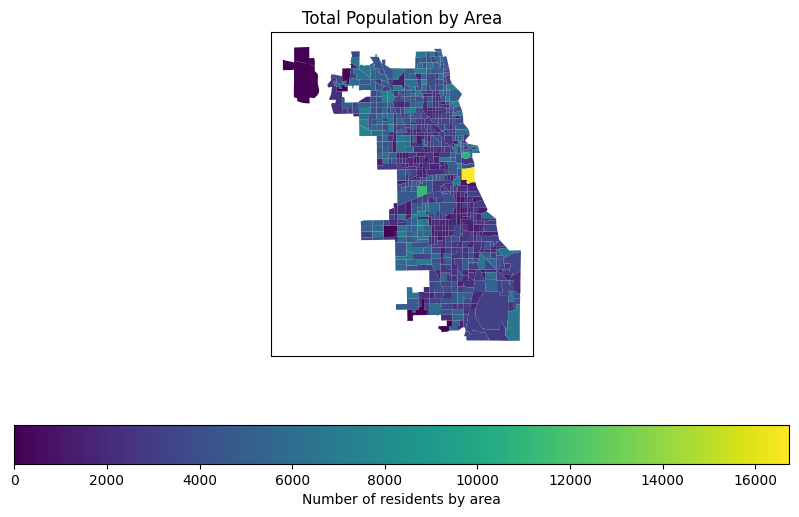

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
gdf_population_merged.plot(column='TOTAL POPULATION', ax=ax, legend=True,
                          legend_kwds={'label': "Number of residents by area",
                                       'orientation': "horizontal"})
plt.title('Total Population by Area')

# remove x and y ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

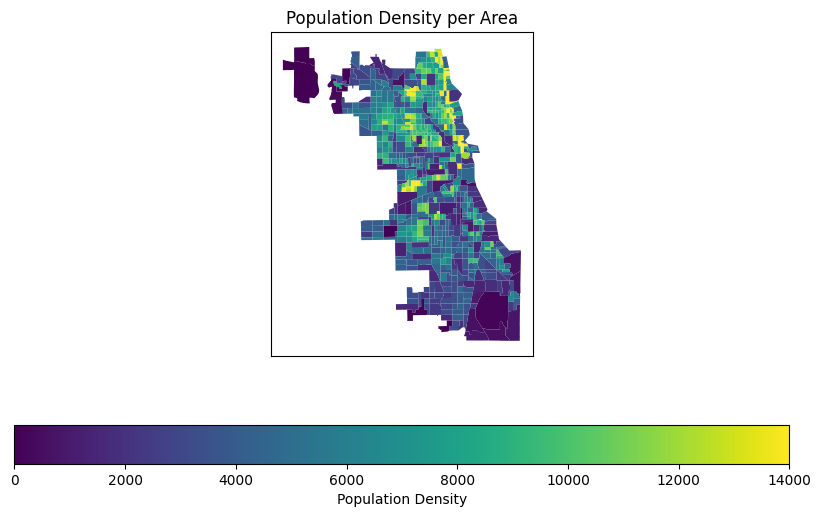

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
gdf_population_merged.plot(column='Population_Density', ax=ax, legend=True,
                          vmin=0, vmax=14000,  # adjust scale
                          legend_kwds={'label': "Population Density",
                                       'orientation': "horizontal"})
plt.title('Population Density per Area')
# remove x and y ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

NameError: name 'gdf_parks' is not defined

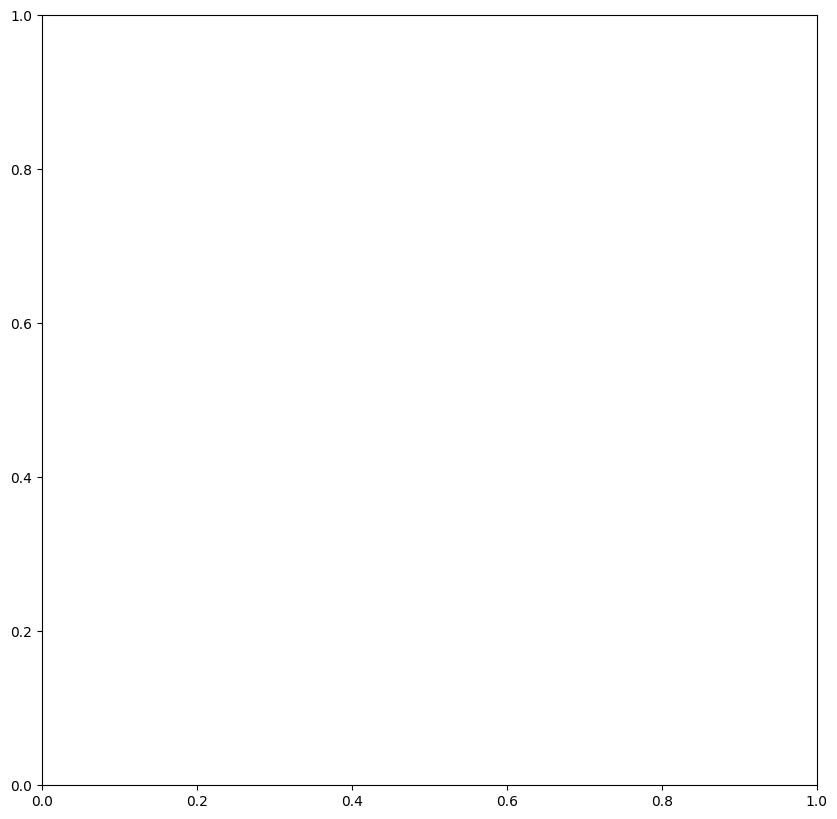

In [47]:
# plot all three
fig, ax = plt.subplots(figsize=(10, 10))

gdf_parks.plot(ax=ax, color='green', edgecolor='green', alpha=0.5)
gdf_boulevards.plot(ax=ax, color='red', edgecolor='red', alpha=0.5)
gdf_riverwalks.plot(ax=ax, color='blue', edgecolor='blue', alpha=0.5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
plt.title('Parks, Boulevards and Riverwalks in Chicago')
# plt.legend(['Parks', 'Boulevards', 'Riverwalks'])
park_patch = mpatches.Patch(color='green', label='Parks')
boulevard_patch = mpatches.Patch(color='red', label='Boulevards')
riverwalk_patch = mpatches.Patch(color='blue', label='Riverwalks')
plt.legend(handles=[park_patch, boulevard_patch, riverwalk_patch])

plt.show()

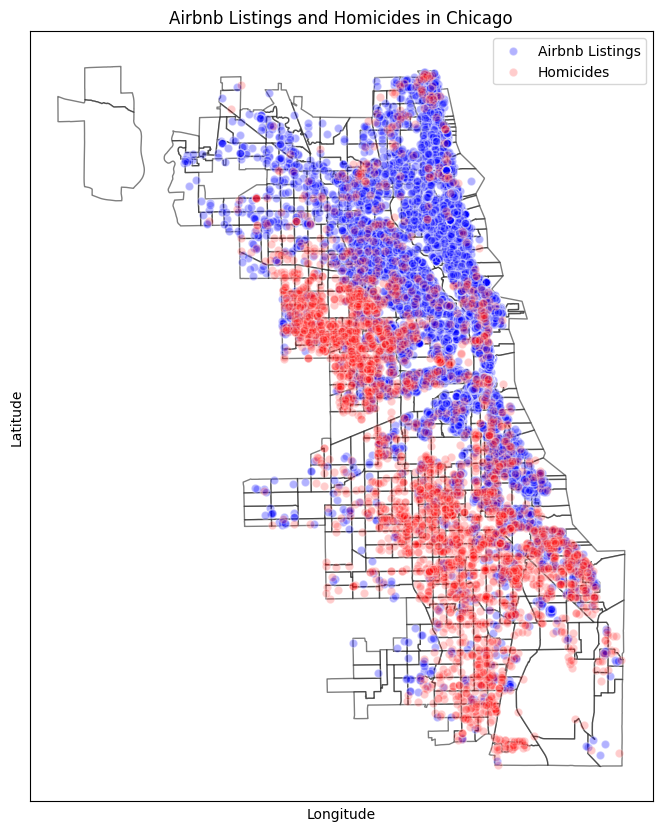

In [48]:
from matplotlib import colors


fig, ax = plt.subplots(figsize=(10, 10))

gdf_population_merged.plot(ax=ax, color='white', edgecolor='black', alpha=0.5)
gdf_listings.plot(ax=ax, color='blue', edgecolor='white', alpha=0.3)
gdf_crime_filtered.plot(ax=ax, color='red', edgecolor='white', alpha=0.2)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
# plot legend with original color not alpha
plt.legend(['Airbnb Listings', 'Homicides'], loc='upper right')
plt.title('Airbnb Listings and Homicides in Chicago')
plt.show()

In [49]:
gdf_listings['geohash'] = gdf_listings.apply(lambda row: geohash.encode(row['latitude'], row['longitude'], precision=5), axis=1)


geometry = [Point(xy) for xy in zip(gdf_listings['longitude'], gdf_listings['latitude'])]
geo_df = gpd.GeoDataFrame(gdf_listings, geometry=geometry)

# Define the boundaries of the  grid
num_of_columns, num_of_rows = 100, 100
minx, miny, maxx, maxy = geo_df.geometry.total_bounds
dx = (maxx - minx) / num_of_columns  # width of grid cell
dy = (maxy - miny) / num_of_rows  # height of grid cell


grid = []
for x in range(num_of_columns):
    for y in range(num_of_rows):
        xmin = minx + x * dx
        xmax = minx + (x+1) * dx
        ymin = miny + y * dy
        ymax = miny + (y+1) * dy
        grid.append(Polygon([(xmin,ymin), (xmax,ymin), (xmax,ymax), (xmin,ymax)]))
grid = gpd.GeoDataFrame(grid, columns=['geometry'], crs=geo_df.crs)


joined = gpd.sjoin(geo_df, grid, how='left', op='within')
joined.head(3)

C:\Users\marku\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3466: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry,geohash,index_right
0,2384,https://www.airbnb.com/rooms/2384,20230912032549,2023-09-12,city scrape,Condo in Chicago · ★4.99 · 1 bedroom · 1 bed ·...,You are invited stay in the guest room of my v...,The apartment is less than one block from beau...,https://a0.muscache.com/pictures/acf6b3c0-47f2...,2613,...,R17000015609,f,1,0,1,0,2.15,POINT (-87.588 41.788),dp3tw,8137.0
1,7126,https://www.airbnb.com/rooms/7126,20230912032549,2023-09-12,city scrape,Rental unit in Chicago · ★4.70 · 1 bedroom · 1...,A very small studio in a wonderful neighborhoo...,"Ukrainian Village was just named ""Hottest Neig...",https://a0.muscache.com/pictures/51073/16c81c7...,17928,...,R21000075737,f,1,1,0,0,2.92,POINT (-87.680 41.902),dp3wk,5267.0
2,10945,https://www.airbnb.com/rooms/10945,20230912032549,2023-09-12,city scrape,Rental unit in Chicago · ★4.65 · 2 bedrooms · ...,Beautiful first floor apartment in Historic Ol...,NaN,https://a0.muscache.com/pictures/58d1a420-a24b...,33004,...,2209984,t,7,7,0,0,0.63,POINT (-87.640 41.912),dp3wm,6570.0


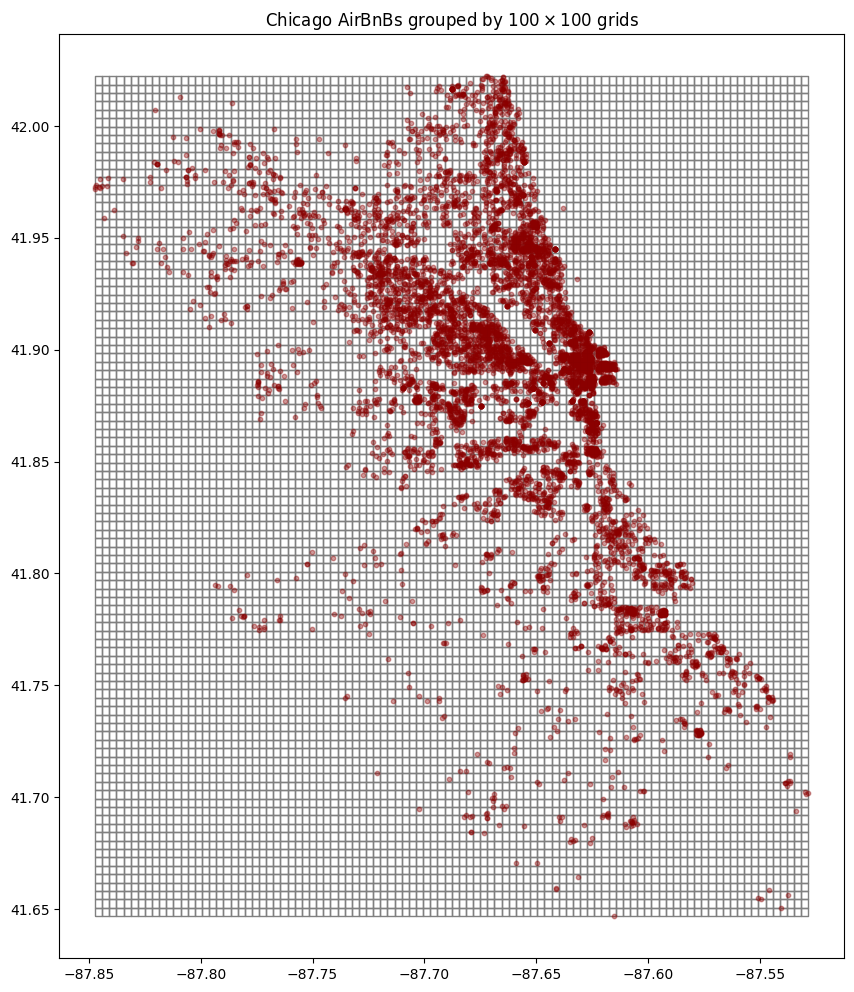

In [50]:
# Plot 1
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
grid.plot(ax=ax, facecolor='none', edgecolor='grey')  # plot grid
joined.plot(ax=ax, markersize=10, color='darkred', alpha=0.4)  # plot the scatters 
plt.title('Chicago AirBnBs grouped by $100\\times100$ grids')
plt.show()

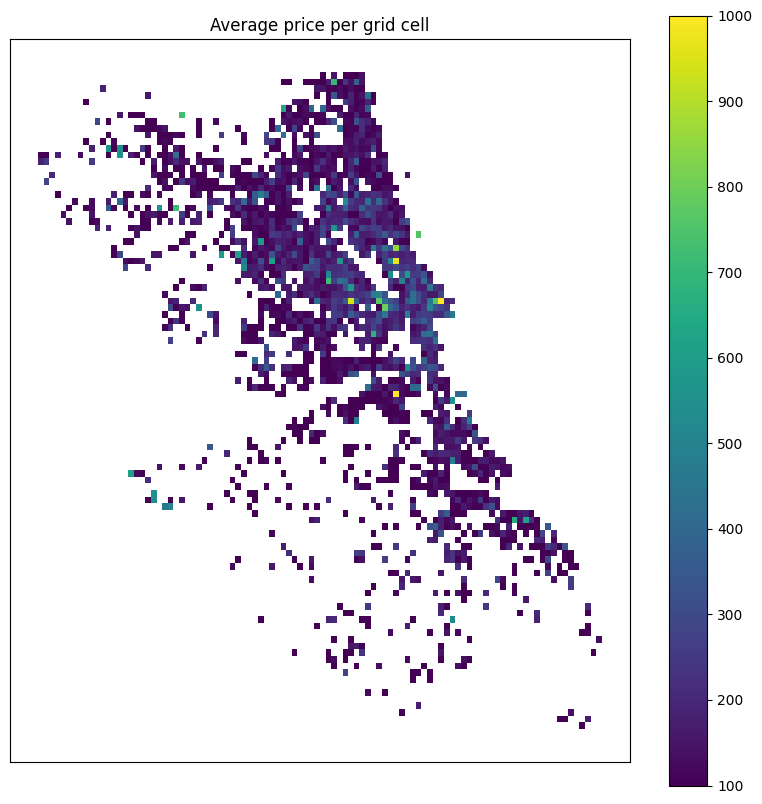

In [51]:
# Plot 2
joined.groupby(joined.index_right)['price'].mean()
average_price = joined.groupby(joined.index_right)['price'].mean()

# join the average prices back to the grid
grid['price'] = average_price

# plot the grid with colors according to the average price
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
vmin = 100  
vmax = 1000  
grid.plot(column='price', ax=ax, legend=True, vmin=vmin, vmax=vmax)
plt.title('Average price per grid cell')

# remove x and y ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

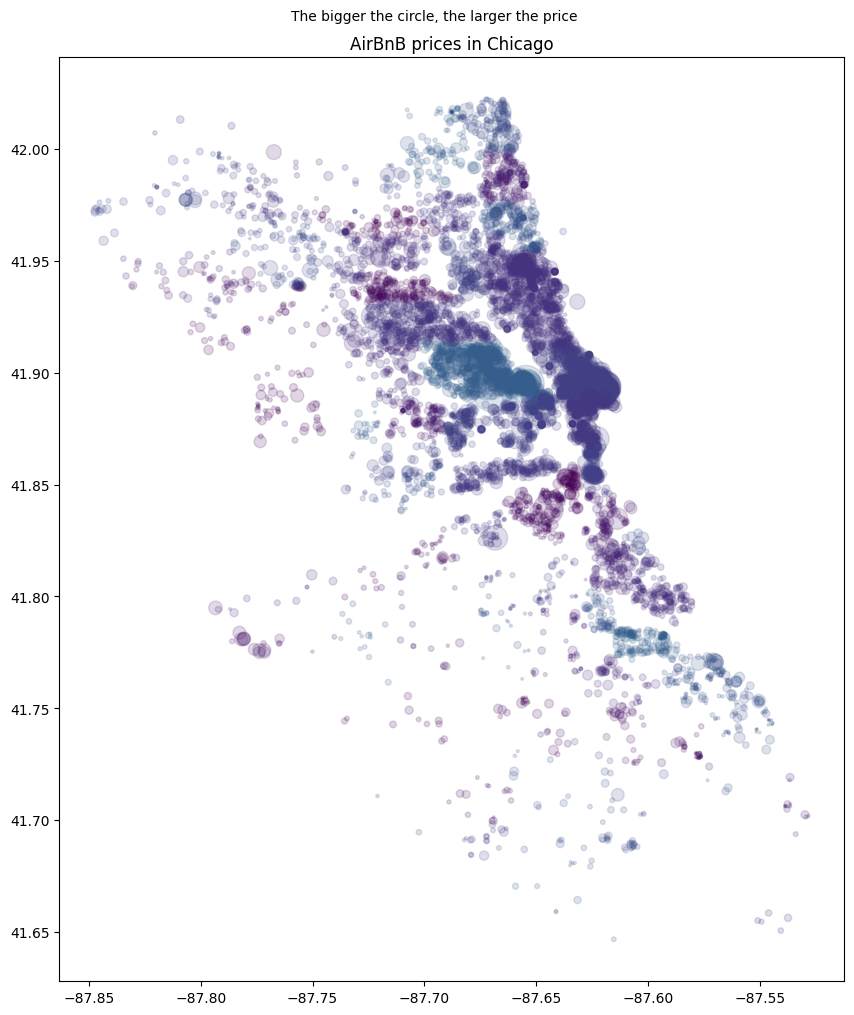

In [52]:
# Plot 3
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# create a color map
cmap = plt.get_cmap('viridis')
colors = cmap(joined['neighbourhood_cleansed'].astype('category').cat.codes)

# create a size variable that is proportional to the price_float value
sizes = joined['price'] / joined['price'].max() * 1200

# plot the scatters 
joined.plot(ax=ax, markersize=sizes, color=colors, alpha=.17)
plt.title('AirBnB prices in Chicago')
plt.suptitle('The bigger the circle, the larger the price', fontsize=10, y=0.92)
plt.show()

## 2.2. Non-Geographic EDA
<a id='non-geographic-eda'></a>

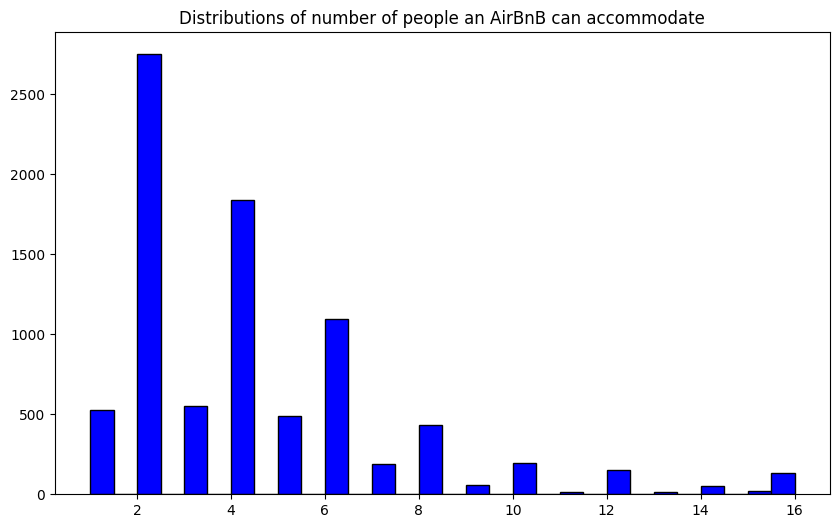

In [53]:
metric = df_listings["accommodates"] # gdf_population_merged['Population_Density']

plt.figure(figsize=(10, 6))
plt.hist(metric, bins=30, color='blue', edgecolor='black')
plt.title('Distributions of number of people an AirBnB can accommodate')
plt.show()

In [54]:
gdf_listings.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

neighbourhood_cleansed
Clearing           351.176471
Near North Side    337.975915
West Town          277.413793
Near South Side    261.841463
Loop               250.688034
                      ...    
Calumet Heights     66.468750
West Lawn           66.000000
West Englewood      61.722222
Fuller Park         59.000000
New City            56.982143
Name: price, Length: 77, dtype: float64

In [55]:
gdf_listings[['neighbourhood_cleansed', 'price', 'bedrooms', 'beds', 'accommodates']].groupby('neighbourhood_cleansed').median().sort_values(by='price')

,price,bedrooms,beds,accommodates
neighbourhood_cleansed,,,,
Calumet Heights,29.0,1.0,1.0,1.0
Fuller Park,31.0,2.5,1.0,2.0
New City,31.5,2.0,1.0,2.0
South Chicago,33.0,2.0,1.0,2.0
East Side,42.0,2.0,1.0,2.0
...,...,...,...,...
Loop,186.5,1.0,1.0,3.0
Burnside,200.0,2.0,2.0,6.0
Ohare,200.0,1.0,1.0,3.0


In [56]:
top_10_nbds = gdf_listings['neighbourhood_cleansed'].value_counts()[:10].index
top_10_nbds

Index(['Near North Side', 'West Town', 'Lake View', 'Near West Side',
       'Logan Square', 'Loop', 'Lincoln Park', 'Near South Side',
       'Lower West Side', 'Uptown'],
      dtype='object', name='neighbourhood_cleansed')

In [57]:
df_top10 = gdf_listings.loc[gdf_listings['neighbourhood_cleansed'].isin(top_10_nbds)]
df_top10.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry,geohash
1,7126,https://www.airbnb.com/rooms/7126,20230912032549,2023-09-12,city scrape,Rental unit in Chicago · ★4.70 · 1 bedroom · 1...,A very small studio in a wonderful neighborhoo...,"Ukrainian Village was just named ""Hottest Neig...",https://a0.muscache.com/pictures/51073/16c81c7...,17928,...,4.75,R21000075737,f,1,1,0,0,2.92,POINT (443579.828 4639081.416),dp3wk
2,10945,https://www.airbnb.com/rooms/10945,20230912032549,2023-09-12,city scrape,Rental unit in Chicago · ★4.65 · 2 bedrooms · ...,Beautiful first floor apartment in Historic Ol...,NaN,https://a0.muscache.com/pictures/58d1a420-a24b...,33004,...,4.65,2209984,t,7,7,0,0,0.63,POINT (446939.361 4640199.221),dp3wm
3,12140,https://www.airbnb.com/rooms/12140,20230912032549,2023-09-12,city scrape,Boutique hotel in Chicago · ★4.93 · 1 bedroom ...,Bed and Breakfast license issued by the City o...,The Guest House is in the heart of Chicago's m...,https://a0.muscache.com/pictures/miso/Hosting-...,46734,...,4.87,R20000055258,f,1,0,1,0,0.15,POINT (446147.997 4641494.278),dp3wm


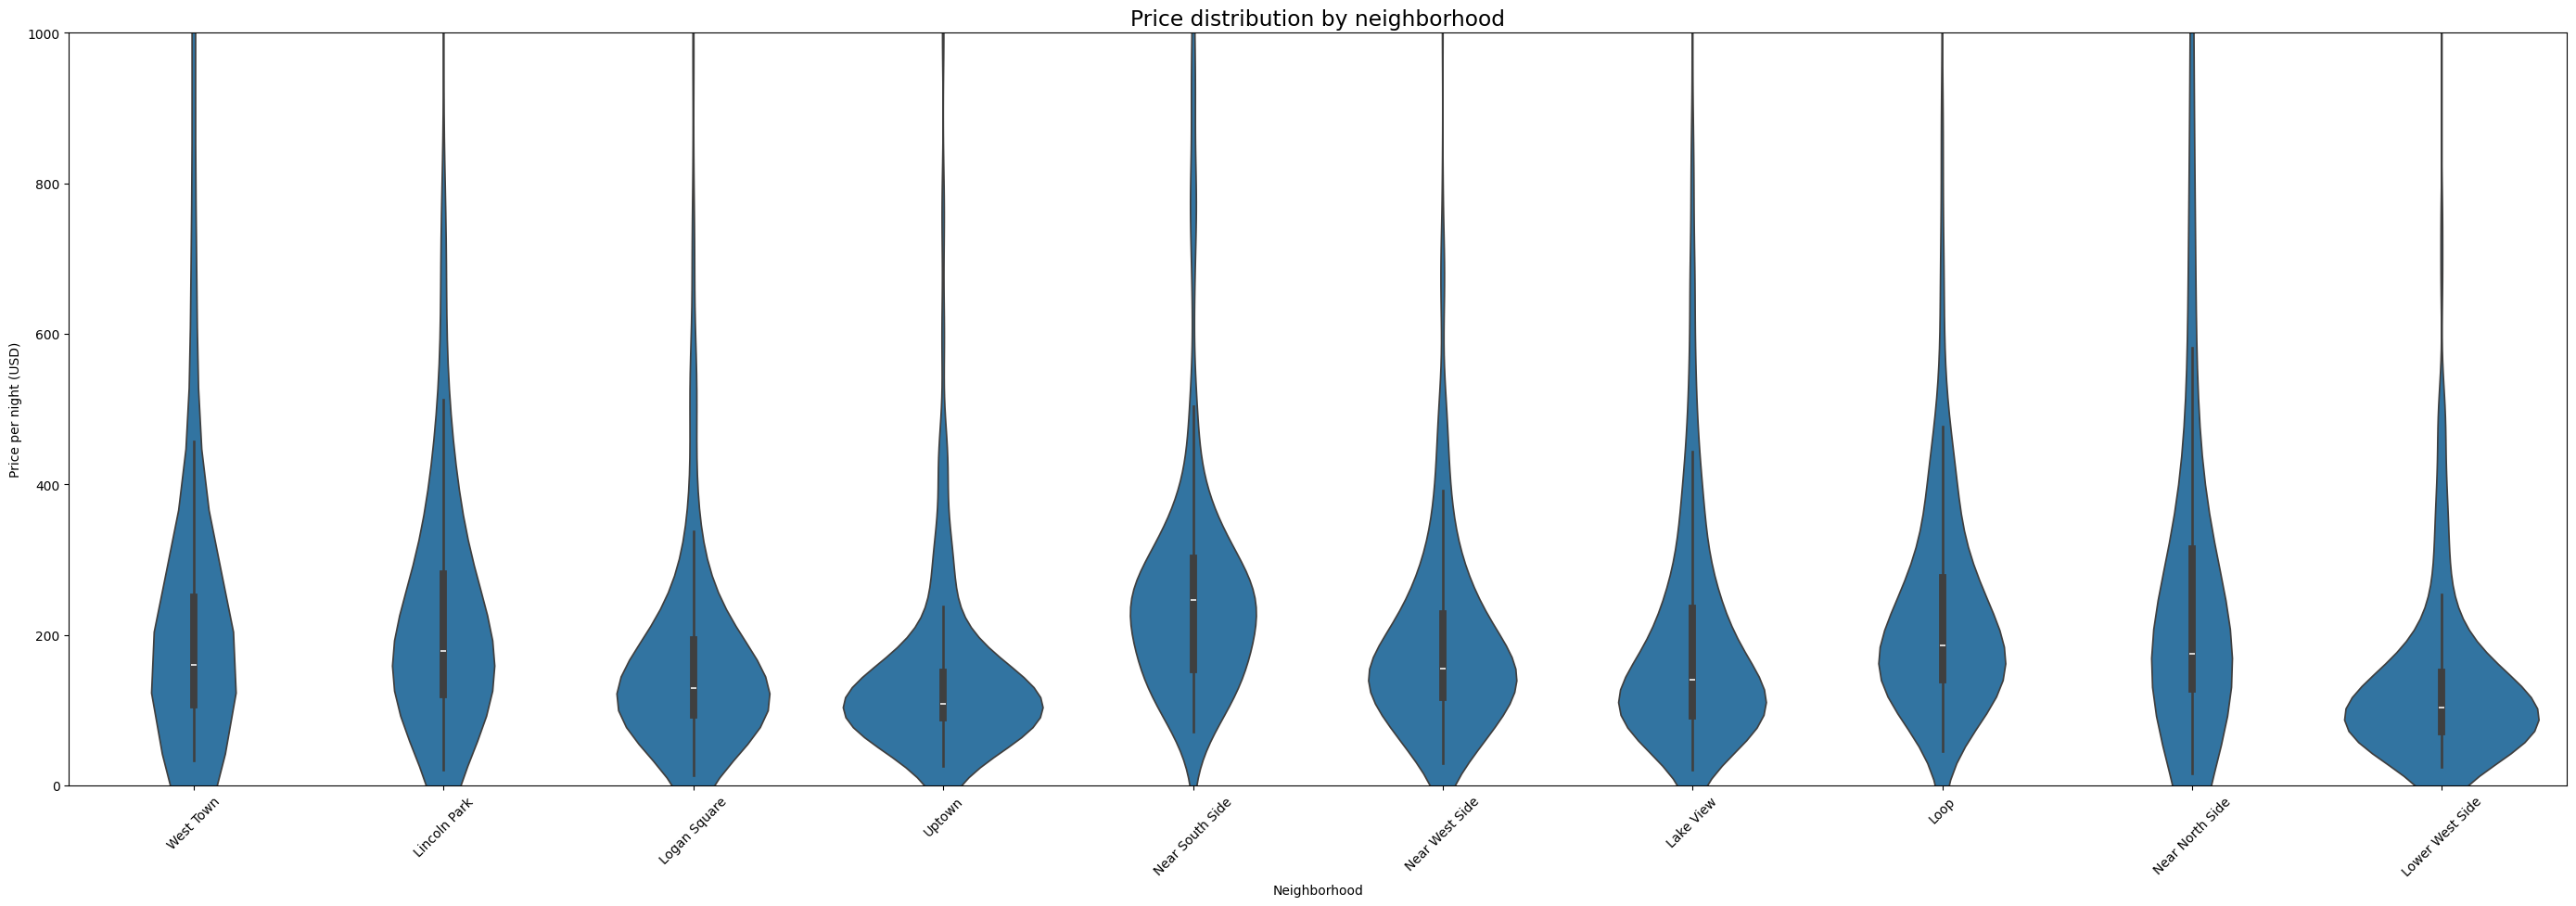

In [58]:
plt.figure(figsize=(28,10))
sns.violinplot(data=df_top10, x='neighbourhood_cleansed', y='price')
plt.rcParams['font.size'] = 14
plt.xticks(rotation=45)
plt.xlabel('Neighborhood')
plt.ylabel('Price per night (USD)')
plt.title('Price distribution by neighborhood')
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

In [51]:
gdf_listings[['neighbourhood_cleansed', 'price', 'bedrooms', 'beds', 'accommodates']].groupby('neighbourhood_cleansed').median().sort_values(by='price')

,price,bedrooms,beds,accommodates
neighbourhood_cleansed,,,,
Calumet Heights,29.0,1.0,1.0,1.0
Fuller Park,31.0,2.5,1.0,2.0
New City,31.5,2.0,1.0,2.0
South Chicago,33.0,2.0,1.0,2.0
East Side,42.0,2.0,1.0,2.0
...,...,...,...,...
Loop,186.5,1.0,1.0,3.0
Burnside,200.0,2.0,2.0,6.0
Ohare,200.0,1.0,1.0,3.0


# 3. In-Depth Analysis & Modeling - Airbnb Locations
<a id='in-depth-analysis-airbnb-locations'></a>
Here, we create a final dataset which is based on "population". When computing further statistics for each district, it's important to account for the district's size ("normalization"). 

In [52]:
# listings data as gdf
gdf_listings = gpd.GeoDataFrame(df_listings, geometry=gpd.points_from_xy(df_listings.longitude, df_listings.latitude))
gdf_listings.crs = 'EPSG:4326'
gdf_listings.to_crs(epsg=26916, inplace=True)  # common projection

# remove one outlier value (faulty data?)
gdf_listings = gdf_listings[gdf_listings['price'] <= 10000]

# only keep certain columns for now
gdf_listings_filtered = gdf_listings[['geometry', 'accommodates', 'price', 'review_scores_location', 
                                      'review_scores_rating', 'reviews_per_month']].copy()
gdf_listings_filtered

TypeError: '<=' not supported between instances of 'str' and 'int'

In [53]:
# join Airbnb and population data
gdf_joined = gpd.sjoin(gdf_listings_filtered, gdf_population_merged, how="inner", op="within")
statistics = gdf_joined.groupby('GEOID10').agg(  # compute various descriptive statistics
    Airbnb_Count=('price', 'count'),
    Median_Price=('price', 'median'),
    Average_Price=('price', 'mean'),
    Median_Review_Score=('review_scores_rating', 'median'))
statistics = statistics.join(gdf_population_merged.set_index('GEOID10')['Area_km2'])

# calculate Airbnbs per km²
statistics['Airbnb_per_km2'] = statistics['Airbnb_Count'] / statistics['Area_km2']

# join back
gdf_population_merged_stats = gdf_population_merged.merge(statistics, on='GEOID10', how='left')
gdf_population_merged_stats.drop(columns=['Area_km2_y'], inplace=True)
gdf_population_merged_stats.rename(columns={'Area_km2_x': 'Area_km2'}, inplace=True)

# add crime counts
gdf_joined_crime = gpd.sjoin(gdf_crime_filtered, gdf_population_merged_stats, how="inner", op="within")
gdf_crime_counts = gdf_joined_crime.groupby('GEOID10').size().reset_index(name='Crime_Count')

# merge back
gdf_population_final = gdf_population_merged_stats.merge(gdf_crime_counts, on='GEOID10', how='left')
gdf_population_final.rename(columns={'Crime_Count_x': 'Crime_Count'}, inplace=True)
gdf_population_final['Crime_Count'].fillna(0, inplace=True)
gdf_population_final['Crimes_per_km2'] = gdf_population_final['Crime_Count'] / gdf_population_final['Area_km2']  # crime density column
gdf_population_final

NameError: name 'gdf_listings_filtered' is not defined

In [54]:
gdf_population_final_nonan = gdf_population_final.dropna(subset=['Median_Price', 'Crime_Count'])  # drop some missings

X = gdf_population_final_nonan[['Crimes_per_km2']]
y = gdf_population_final_nonan['Airbnb_per_km2']
X = sm.add_constant(X)  # add a constant to the model (the intercept)

model = sm.OLS(y, X).fit()

print(model.summary())

NameError: name 'gdf_population_final' is not defined

# 4. In-Depth Analysis & Modeling - Airbnb Prices
<a id='in-depth-analysis-airbnb-prices'></a>

In a first step, we will extend the gdf_listings by some further data. We add 3 columns:

* `crime_count` which tells us how many homicides occured in a 2km radius
* `distance_to_center` which gives the distance to the city center
* `has_park_within_100m` which gives a boolean indicator whether there is a park nearby

In [55]:
if 'buffer' not in gdf_listings.columns:
    gdf_listings['buffer'] = gdf_listings['geometry'].buffer(2000)  # 2000 meters = 2km

if 'gdf_listings_buffer' not in locals():
    gdf_listings_buffer = gdf_listings[['id', 'buffer']].copy()
    gdf_listings_buffer.set_geometry('buffer', inplace=True)

# Perform the spatial join
joined = gpd.sjoin(gdf_listings_buffer, gdf_crime_filtered, how='left', op='intersects')

# Count the crimes and merge with the original dataframe
crime_count = joined.groupby('id').size().reset_index(name='crime_count_temp')
gdf_listings = gdf_listings.merge(crime_count, on='id', how='left')

# Update crime_count column
gdf_listings['crime_count'] = gdf_listings['crime_count_temp'].fillna(0)
gdf_listings.drop(['buffer', 'crime_count_temp'], axis=1, inplace=True, errors='ignore')

/Users/markus/GitHub/VIZZ/AirBnB/ABNBVENV/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3639: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.


In [ ]:
gdf_listings[["id", "crime_count"]].head(3)

In [ ]:
# Get distance to city center for each airbnb

# Create a Point object for the given coordinates
center_point = Point(448156, 4635454)

# Calculate distances and add/update the column in gdf_listings
if 'distance_to_center' in gdf_listings.columns:
    # Update the column if it already exists
    gdf_listings['distance_to_center'] = gdf_listings['geometry'].distance(center_point)
else:
    # Create the column if it does not exist
    gdf_listings = gdf_listings.assign(distance_to_center=gdf_listings['geometry'].distance(center_point))

In [ ]:
def plot_price_relationships(x:str, facet:str, ax_scaling:str='free', outlier_cutoff:float=6000):
    g =(ggplot(gdf_listings[gdf_listings['price'] <= outlier_cutoff], # filter out the outlier
            aes(x=x, y='price', color=facet)) +
            geom_point(color='black', alpha=0.2, size=2, stroke=0.4) +
            geom_smooth(method='lm', color='r', se=False) +
            facet_wrap(facets=facet, scales=ax_scaling) 
    )
    return g

plot_price_relationships(x='accommodates', facet='room_type', ax_scaling='fixed')

In [ ]:
def plot_price_relationships_r2(x:str, facet:str, df:pd.DataFrame=gdf_listings, ax_scaling:str='free', outlier_cutoff:float=6000):
    import warnings
    warnings.filterwarnings("ignore")
    df = df[df['price'] <= outlier_cutoff]
    
    # calculate R^2 for each facet
    facets = df[facet].unique()
    r2_values = {}
    for f in facets:
        model = smf.ols(formula=f'price ~ {x}', data=df[df[facet] == f]).fit()
        # r2_values[f] = f"R2 = {round(model.rsquared, 4)}"
        # r2_values[f] = f"$R^2$ = {round(model.rsquared, 4)}\n$\\beta$ = {round(model.params[x],2)}"
        r2_values[f] = f"$R^2$ = {round(model.rsquared, 4)}\n$\\beta$ = {round(model.params[x],2)}\n$p$ = {round(model.pvalues[x],4)}"
    
    # create a new dataframe for R^2 values
    r2_df = pd.DataFrame(list(r2_values.items()), columns=[facet, 'R2'])
    g = (ggplot(df, aes(x=x, y='price', color=facet)) +
         geom_point(color='black', alpha=0.2, size=2, stroke=0.4) +
         geom_smooth(method='lm', color='r', se=False) +
         geom_text(data=r2_df, mapping=aes(label='R2'), color='b', x=len(df[x].unique())/4, y=outlier_cutoff-1700) +
         facet_wrap(facets=facet, scales=ax_scaling))
    return g

plot_price_relationships_r2(x='accommodates', facet='room_type', ax_scaling='fixed')



In [ ]:
facet = 'host_response_time'
plot_price_relationships(x='accommodates', facet=facet)

In [ ]:
plot_price_relationships_r2(x='beds', facet='room_type', ax_scaling='fixed')

In [ ]:
plot_price_relationships_r2(x='accommodates', facet='property_type', ax_scaling='fixed') + theme(aspect_ratio=1, figure_size=(25, 20))

In [ ]:
facet = 'room_type'
plot_price_relationships_r2(x='review_scores_cleanliness', facet=facet, ax_scaling='fixed')

## 4.1 K-means clustering
<a id='k-means-clustering'></a>
-  ```StandardScaler```: subtracting mean, dividing by stdev $\to$ $x_{scaled}=\frac{x - \bar{x}}{\sigma}$  
-  ```MinMaxScaler```: scaling to squish values btw 0 and 1 $\to$ $x_{scaled}=(\frac{x - x_{min}}{x_{max}- x_{min}}) \times (x_{max}- x_{min}) - x_{min}$  

### 4.1.1 Data Processing steps
<a id='data-processing-steps'></a>

In [ ]:
property_type = gdf_listings['property_type'].tolist()
pt_dict = {}
for pt in property_type:
    if pt in pt_dict:
        pt_dict[pt] += 1
    else:
        pt_dict[pt] = 1
sorted(pt_dict.items(), key=lambda item: item[1], reverse=False)

In [ ]:
def convert_object_to_numeric(dataframe:pd.DataFrame):
    df = dataframe.copy()
    for col in df.columns:
        try:
            df[col] = df[col].astype('int64')
        except TypeError:
            try:
                df[col] = df[col].astype('float64')
            except TypeError:
                pass
        except ValueError:
            try:
                df[col] = df[col].astype('float64')
            except ValueError:
                pass
    return df

numerical_df = convert_object_to_numeric(gdf_listings)
numerical_df = numerical_df.select_dtypes(include=['int64', 'float64'])

In [ ]:
numerical_df2 = numerical_df.copy()
numerical_df2.drop(['neighbourhood_group_cleansed','bathrooms','calendar_updated','reviews_per_month',
                   'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 
                   'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value',
                    'latitude', 'longitude', 'availability_30'], axis=1, inplace=True)
numerical_df2['bedrooms'].fillna(1, inplace=True)
numerical_df2['beds'].fillna(1, inplace=True)
print(numerical_df2['bedrooms'].isna().sum())
print(numerical_df2['beds'].isna().sum())

In [ ]:
numerical_df3 = numerical_df2[['accommodates', 'bedrooms', 'beds', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'price']]
numerical_df3.shape

### 4.1.2 The Model
<a id='the-model'></a>

In [ ]:
stds = StandardScaler()
mmxs = MinMaxScaler()

df_std = pd.DataFrame(stds.fit_transform(numerical_df3))
df_mmx = pd.DataFrame(mmxs.fit_transform(numerical_df3))
df_std.columns, df_mmx.columns = numerical_df3.columns, numerical_df3.columns
display(df_std.head())
display(df_mmx.head())

In [ ]:
# X = numerical_df3.values
X = df_std.values

# kmeans = KMeans(n_clusters=8, init='k-means++', n_init='warn', max_iter=300, tol=0.0001, verbose=1, random_state=None, copy_x=True, algorithm='lloyd')
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)

In [ ]:
numerical_df3['cluster'] = kmeans.labels_
df_std['cluster'] = kmeans.labels_
numerical_df3.head()

In [ ]:
# drop overlapping columns from the right dataframe before the merge
joined = pd.read_csv(airbnb_data_path + "listings.csv.gz")
joined = joined.dropna(subset=['price']) # remove missings
joined['price'] = joined['price'].astype(str)
joined['price'] = joined['price'].str.replace('$', '').str.replace(',', '').astype(float)
columns_to_drop = [col for col in joined.columns if col in numerical_df2.columns and col not in ['id', 'price']]

joined_drop = joined.drop(columns=columns_to_drop, inplace=False)

joined2 = numerical_df2.merge(joined_drop, on=['id', 'price'])
print(joined_drop.shape)
print(joined2.columns)
print(joined2.shape)
print(len(kmeans.labels_))

In [ ]:
# drop overlapping columns from the right dataframe before the merge
columns_to_drop = [col for col in joined.columns if col in numerical_df3.columns and col not in ['accommodates', 'bedrooms', 'beds', 'availability_60', 
                                                                                                 'availability_90', 'availability_365', 'number_of_reviews', 'price']]
joined_drop = joined.drop(columns=columns_to_drop, inplace=False)


joined3 = numerical_df3.merge(joined_drop, on=['accommodates', 'bedrooms', 'beds', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'price'])
joined3 = pd.concat([joined2, numerical_df3['cluster']], axis=1)
joined3.columns

In [ ]:
# joined2['cluster'] = joined2['cluster'].astype('str')
joined3['cluster'] = joined3['cluster'].astype('str')
joined3.cluster.value_counts()

In [ ]:
custom_color_sequence = ["blue", "red", 'fuchsia', 'green']

# min(merged_df['price_float']); max(merged_df['price_float'])
beds = gdf_listings['beds'].fillna(0).tolist()

# joined3 = joined3.merge(gdf_listings[['id', 'longitude', 'latitude']], on=['id'])
joined3 = pd.concat([joined3, joined[['latitude', 'longitude']]])

print("Interactive geoplot:\ndot color -> cluster\ndot size -> price (higher price, bigger dot)")
fig = px.scatter_mapbox(joined3, lat="latitude", lon="longitude", hover_name="beds",
                        hover_data=["price", "beds"],
                        color="cluster", zoom=10, height=500, size=joined3['beds'].fillna(0.5)*10000, opacity = 0.65, size_max = 15, #size=[80]*merged_df.shape[0],
                        # color_discrete_sequence = custom_color_sequence,
                        color_continuous_scale="Jet",
                        range_color=[100, 700])

fig.update_layout(mapbox_style="open-street-map")
fig.update_geos(projection_type="natural earth")
fig.update_layout(margin={"r":0, "t":0, "l":0, "b":0})
fig.show()

In [ ]:
#let's see what factors contributed to the clusters
cmap='YlGnBu'
print('true values:')
display(numerical_df3.groupby('cluster').mean().style.background_gradient(cmap=cmap))

print('scaled values:')
display(df_std.groupby('cluster').mean().style.background_gradient(cmap=cmap))

## 4.2 Associate Rule Learning (unsupervised co-occurence analysis)
<a id='associate-rule-learning'></a>

In [ ]:
gdf_listings.columns

In [ ]:
gdf_listings['amenities'] = gdf_listings['amenities'].astype('str')
amenities = gdf_listings['amenities']

ls_amen = amenities.apply(lambda x: len(x.strip('[]').split(','))).to_list() # strip and split required as amenities col actually contains lists in str format
max_len = max(ls_amen)
idx = ls_amen.index(max_len)

print(f"the longest list contains {max_len} amenities")

len(gdf_listings['amenities'].iloc[idx].strip('[]').split(',')) == max_len


In [ ]:
# preprocessing -> converting amenities column to actual lists
gdf_listings['amenities_list'] = gdf_listings['amenities'].apply(lambda x: x.strip('[]').split(','))

gdf_listings['amenities_list'][:5]

In [ ]:
amenities_df = pd.DataFrame(gdf_listings['amenities_list'].apply(set))


amenities_ls = gdf_listings['amenities_list']
flattened_list = [elem for sub_ls in amenities_ls for elem in sub_ls]


amenities_columns = pd.DataFrame(columns=list(set(sorted(flattened_list))))


amenities_df = pd.concat([amenities_df, amenities_columns], axis=1)

amenities_df.fillna(0, inplace=True)

for idx, row in amenities_df.iterrows(): #omit first column which contains the lists
    # get the amenities for the current row
    amenities = amenities_ls.loc[idx]
    
    for amenity in amenities:
        # if the amenity is in the DataFrame columns, set its value to 1
        if amenity in amenities_df.columns:
            amenities_df.loc[idx, amenity] = 1
                

In [ ]:
amenities_df.shape

In [ ]:
amenities_dummies = amenities_df.drop(columns=['amenities_list'])

amenities_dummies.info()

Metrics used in associate rule mining are the following:

- **Support**

It indicates how frequently an item set appears in the data set.

Let $frq(A)$ be the number of occurrences (frequency) from the total number of transactions $frq(T) = T$:

$$
supp(A) = \frac{frq(A)}{T}
$$


- **Confidence**

It says how likely item set B is purchased when item set A is purchased

$$
conf(A \to B) = \frac{supp(A,B)}{supp(A)}
$$

with $supp(A,B) = \frac{frq(A,B)}{frq(T)}$ and $supp(A) = \frac{frq(A)}{frq(T)}$ it holds that:

$$
conf(A \to B) = \frac{supp(A,B)}{supp(A)} = 
\frac{\frac{frq(A,B)}{frq(T)}}{\frac{frq(A)}{frq(T)}} = 
\frac{frq(A,B)}{frq(A)}
$$

- **Lift**

Lift: It says how likely item set B is purchased when item set A is purchased while controlling for how popular item set B is.

Lift is the ratio of the observed support to that expected if A and B were independent or equivalently the ratio of the confidence of the rule to the expected confidence of the RHS item set by independence.

$$
lift(A \to B) = \frac{conf(A,B)}{supp(B)} = \frac{supp(A,B)}{supp(A) \times supp(B)}
$$

Note:

$$
lift(A \to B) == lift(B \to A)
$$


In [ ]:
def support(df, cols):
  if type(cols) != list:
    cols = [cols]
    #cols = np.array(cols)
  #print(cols)
  bool_mask = df[cols].isin([1]).all(axis=1)
  frqA = len(df[bool_mask])
  T = len(df[cols])
  return frqA/T

# item set of 3 different products
# print(support(retail, ["Bread", "Yogurt", "Egg"]))
# # also works with single item sets
# support(retail,'Bread')
  

def confidence(df, A, B):
  if type(A)==list and type(B)==list:
    AB = A + B
  elif type(A)==list and type(B)!=list:
    AB = A
    AB.append(B)
  elif type(A)!=list and type(B)==list:
    AB = B
    AB.append(A)
  elif type(A)!=list and type(B)!=list:
    AB = [A, B]
  return support(df, AB) / support(df, A)

# print(confidence(retail, "Bread", "Egg"))

# confidence(retail, ["Bread"], ["Dog_Food","Flowers"])


def lift(df, A, B):
  return confidence(df, A, B) / support(df, B)

# lift(retail, "Bread", "Egg")

In [ ]:
# Calculate support for each amenity
support_values = {amenity: support(amenities_dummies, amenity) for amenity in amenities_dummies.columns}

# Filter amenities with support > 10%
filter_amenities = [amenity for amenity, support in support_values.items() if support > 0.15]
print("number of features with support > 15%:", len(filter_amenities))

amenities_names = amenities_dummies[filter_amenities].columns

lift_vals = {}

for i, a1 in enumerate(amenities_names):
    for a2 in amenities_names[i:]:
        if a1 != a2:
            # print(f"lift of {a1} and {a2} is {lift(amenities_dummies, a1, a2)}")
            lift_value = lift(amenities_dummies, a1, a2)
            combo = f"{a1} & {a2}"
            lift_vals[combo] = lift_value


In [ ]:
highest_lift = sorted(lift_vals.items(), key=lambda item: item[1], reverse=True)[:10]
pd.DataFrame(highest_lift, columns=['Itemsets', 'Lift']).style.background_gradient(cmap=cmap)



- If the lift is equal to 1, it means that the antecedent and the consequent are independent of each other. When two events are independent of each other, no rule can be drawn involving those two events.

- If the lift is greater than 1, it means that the antecedent and the consequent are positively correlated. This indicates that the occurrences of the antecedent and the consequent are dependent on one another, and the rule could be useful for predicting the consequent in future data sets.

- If the lift is less than 1, it means that the antecedent and the consequent are negatively correlated.

So, a lift value of 4.182987 means that the antecedent and the consequent are positively correlated and occur together more than 4 times as often as would be expected if they were independent. This suggests a strong association between the antecedent and the consequent.


further analysis of the amenities column

In [ ]:
amenities_dummies['price'] = gdf_listings['price']

# removing outlier
amenities_dummies = amenities_dummies[amenities_dummies['price'] <= 25000]

average_price = {}
median_price = {}
for col in amenities_dummies.columns:
    if col != 'price' and amenities_dummies[col].sum() > 3:
        average_price[col] = amenities_dummies[amenities_dummies[col] == 1]['price'].mean()
        median_price[col] = amenities_dummies[amenities_dummies[col] == 1]['price'].median()


In [ ]:
amenities_count = pd.DataFrame(amenities_dummies[amenities_dummies.columns[:-1]].sum().sort_values(ascending=False), columns=['count'])
amenities_count.reset_index(inplace=True)
amenities_count.rename(columns={'index': 'amenity'}, inplace=True)
amenities_count.head()

In [ ]:
avg = pd.DataFrame(sorted(average_price.items(), key=lambda item: item[1], reverse=True), columns=['amenity', 'average_price'])
med = pd.DataFrame(sorted(median_price.items(), key=lambda item: item[1], reverse=True), columns=['amenity', 'median_price'])

avg = avg.merge(amenities_count, on='amenity')
med = med.merge(amenities_count, on='amenity')


combined = avg.merge(med, on=['amenity', 'count'], suffixes=('_avg', '_med'))
combined['diff'] = abs(combined['average_price'] - combined['median_price'])
combined = combined.sort_values(by='diff', ascending=False)
combined.head(20).style.background_gradient(cmap='RdYlGn_r', subset=['average_price', 'median_price', 'count', 'diff'])

Features which we also want to consider in predicting the price

In [ ]:
# SELECTING THE AMENITIES WHICH HAVE A DIFFERENCE OF 10% OR LESS BETWEEN THE AVERAGE AND MEDIAN PRICE
features_df = combined[combined['diff'] <= ((combined['average_price']+ combined['median_price'])/2) * 0.1] \
            .sort_values(by=['median_price', 'average_price', 'count'], ascending=False) 
features_df.head(20).style.background_gradient(cmap='RdYlGn_r', subset=['average_price', 'median_price', 'count', 'diff'])

In [ ]:
features = features_df['amenity'][:20].tolist()
print('the following features will be considered by the feature selector:\n')
for feature in features:
    print(feature)

## 4.3 Supervised learning
<a id='supervised-learning'></a>

Trying to predict Airbnb prices and see which features are relevant.

### 4.3.1 Data processing
<a id='data-processing'></a>

In [ ]:
room_types = pd.get_dummies(gdf_listings['room_type'])
room_types = room_types.astype(int)

# num_df_for_ml = pd.concat([numerical_df2, room_types, amenities_df[features]], axis=1)
num_df_for_ml = pd.concat([numerical_df2, room_types], axis=1)

num_df_for_ml.drop(['id', 'host_id', 'scrape_id'], inplace=True, axis=1)
num_df_for_ml

In [ ]:
na_col = num_df_for_ml.isnull().sum()

### 4.3.2 Train-test split
<a id='train-test-split'></a>

In [ ]:
def create_split(df:pd.DataFrame, valid_size:float):
    # Separate features and target variable
    X = df.drop(columns='price')
    y = df['price']

    # Split the data into train and validation sets
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=valid_size)

    return X_train, y_train, X_valid, y_valid

In [ ]:
X_train, y_train, X_test, y_test = create_split(num_df_for_ml, valid_size=0.2)

### 4.3.3 Choosing suitable ML
<a id='choosing-suitable-ml'></a>

In [ ]:
#We choose to train Random Forest Regressor for this task. Then we will compare it with simple Linear regression.

ml_methods = []

ml_methods.append(RandomForestRegressor)
ml_methods.append(LinearRegression)
ml_methods.append(XGBRegressor)


In [ ]:
def predict_price(X_train: pd.DataFrame, y_train: pd.DataFrame, X_test: pd.DataFrame, model_class: type, cv: int = 5) -> tuple:
    y_pred = None
    trained_model = None
    
    # Initialize the model
    trained_model = model_class()
    
    # Fit the model on the entire training data
    trained_model.fit(X_train, y_train)

    y_pred = trained_model.predict(X_test)

    return y_pred, trained_model

### 4.3.4 Feature Selection
<a id='feature-selection'></a>

In [ ]:
def create_split_with_features(df: pd.DataFrame, valid_size: float, num_features: int):
    # Separate features and target variable
    X = df.drop(columns='price')
    y = df['price']

    # Feature selection
    selector = RFE(RandomForestRegressor(), n_features_to_select=num_features)
    selector.fit(X, y)
    X_selected = selector.transform(X)
    features = [col for col, selected in zip(X.columns, selector.support_) if selected]

    print("Num Features: %s" % (selector.n_features_))
    print("Selected Features: %s" % (features))

    # Split the data into train and validation sets
    X_train, X_valid, y_train, y_valid = train_test_split(X_selected, y, test_size=valid_size)

    return X_train, y_train, X_valid, y_valid

### 4.3.5 Scale features
<a id='scale-features'></a>

In [ ]:
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [ ]:
# Create split with 10 features
X_train_10, y_train, X_test_10, y_test = create_split_with_features(num_df_for_ml, valid_size=0.2, num_features=10)
X_train_10_scaled, X_test_10_scaled = scale_features(X_train_10, X_test_10)

# Create split with 15 features
X_train_15, y_train, X_test_15, y_test = create_split_with_features(num_df_for_ml, valid_size=0.2, num_features=15)
X_train_15_scaled, X_test_15_scaled = scale_features(X_train_15, X_test_15)

# Create split with 20 features
X_train_20, y_train, X_test_20, y_test = create_split_with_features(num_df_for_ml, valid_size=0.2, num_features=20)
X_train_20_scaled, X_test_20_scaled = scale_features(X_train_20, X_test_20)

# 5. Metrics & Evaluation
<a id='metrics-evaluation'></a>

In [ ]:
suitable_metrics = []

suitable_metrics.append(sklearn.metrics.mean_squared_error)
suitable_metrics.append(sklearn.metrics.mean_absolute_error)
def rmse(y_true, y_pred):
    return np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
suitable_metrics.append(rmse)
suitable_metrics.append(sklearn.metrics.r2_score)

In [ ]:
def compare_metrics(y_true:pd.DataFrame, y_pred:pd.DataFrame) -> dict:
    scores = {}  # dict of metric name -> metric value/score
    
    for metric in suitable_metrics:
        metric_name = metric.__name__
        
        score = metric(y_true, y_pred)
        
        scores[metric_name] = score

    return scores

def print_scores(scores: dict, model_name: str):
  print(f"\nScores:\t{model_name}\n================================")
  for metric_name, metric_value in scores.items():
    print(f"{metric_name}: {metric_value}")

In [ ]:
def compare_models(X_train, y_train, X_test):
    # Train Random Forest model with selected features
    y_pred_rf, _ = predict_price(X_train, y_train, X_test, RandomForestRegressor)

    # Train Linear Regression model with selected features
    y_pred_lin, _ = predict_price(X_train, y_train, X_test, LinearRegression)

    # Train XGBRegressor model with selected features
    y_pred_xgb, _ = predict_price(X_train, y_train, X_test, XGBRegressor)

    return y_pred_rf, y_pred_lin, y_pred_xgb

In [ ]:
def plot_metrics_evolution(metric_values, model_names, feature_counts, metric_name):
    plt.figure(figsize=(10, 6))
    
    for i, model_values in enumerate(metric_values):
        plt.plot(feature_counts, model_values, label=model_names[i])

    plt.title(f'{metric_name} Evolution for different Models')
    plt.xlabel('Number of Features')
    plt.ylabel(metric_name)
    plt.legend()
    plt.show()

In [ ]:
# Performance with 10 features
y_pred_rf_10, y_pred_lin_10, y_pred_xgb_10 = compare_models(X_train_10_scaled, y_train, X_test_10_scaled)

metrics_scores_sel_10 = compare_metrics(y_test, y_pred_rf_10)
metrics_scores_lin_10 = compare_metrics(y_test, y_pred_lin_10)
metrics_scores_xgb_10 = compare_metrics(y_test, y_pred_xgb_10)

print("\nPerformance with 10 features:")
print_scores(metrics_scores_sel_10, model_name='Random Forest')
print_scores(metrics_scores_lin_10, model_name='Linear Regression')
print_scores(metrics_scores_xgb_10, model_name='XGBRegressor')

# Performance with 15 features
y_pred_rf_15, y_pred_lin_15, y_pred_xgb_15 = compare_models(X_train_15_scaled, y_train, X_test_15_scaled)

metrics_scores_sel_15 = compare_metrics(y_test, y_pred_rf_15)
metrics_scores_lin_15 = compare_metrics(y_test, y_pred_lin_15)
metrics_scores_xgb_15 = compare_metrics(y_test, y_pred_xgb_15)

print("\nPerformance with 15 features:")
print_scores(metrics_scores_sel_15, model_name='Random Forest')
print_scores(metrics_scores_lin_15, model_name='Linear Regression')
print_scores(metrics_scores_xgb_15, model_name='XGBRegressor')

# Performance with 20 features
y_pred_rf_20, y_pred_lin_20, y_pred_xgb_20 = compare_models(X_train_20_scaled, y_train, X_test_20_scaled)

metrics_scores_sel_20 = compare_metrics(y_test, y_pred_rf_20)
metrics_scores_lin_20 = compare_metrics(y_test, y_pred_lin_20)
metrics_scores_xgb_20 = compare_metrics(y_test, y_pred_xgb_20)

print("\nPerformance with 20 features:")
print_scores(metrics_scores_sel_20, model_name='Random Forest')
print_scores(metrics_scores_lin_20, model_name='Linear Regression')
print_scores(metrics_scores_xgb_20, model_name='XGBRegressor')

In [ ]:
# Plotting Metrics Evolution
metric_names = ['mean_squared_error', 'mean_absolute_error', 'rmse', 'r2_score']
feature_counts = [10, 15, 20]

for metric_name in metric_names:
    plot_metrics_evolution(
        [[metrics_scores_sel_10[metric_name], metrics_scores_sel_15[metric_name], metrics_scores_sel_20[metric_name]],
         [metrics_scores_lin_10[metric_name], metrics_scores_lin_15[metric_name], metrics_scores_lin_20[metric_name]],
         [metrics_scores_xgb_10[metric_name], metrics_scores_xgb_15[metric_name], metrics_scores_xgb_20[metric_name]]],
        ['Random Forest', 'Linear Regression', 'XGBRegressor'],
        feature_counts,
        metric_name
    )

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], '--k', linewidth=2)
    plt.title(title)
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()

In [ ]:
plot_actual_vs_predicted(y_test, y_pred_rf_10, 'Random Forest - 10 Features')
plot_actual_vs_predicted(y_test, y_pred_lin_10, 'Linear Regression - 10 Features')
plot_actual_vs_predicted(y_test, y_pred_xgb_10, 'XGBRegressor - 10 Features')

plot_actual_vs_predicted(y_test, y_pred_rf_15, 'Random Forest - 15 Features')
plot_actual_vs_predicted(y_test, y_pred_lin_15, 'Linear Regression - 15 Features')
plot_actual_vs_predicted(y_test, y_pred_xgb_15, 'XGBRegressor - 15 Features')

plot_actual_vs_predicted(y_test, y_pred_rf_20, 'Random Forest - 20 Features')
plot_actual_vs_predicted(y_test, y_pred_lin_20, 'Linear Regression - 20 Features')
plot_actual_vs_predicted(y_test, y_pred_xgb_20, 'XGBRegressor - 20 Features')

**Analysis**

The analysis aims to predict Airbnb prices using different combinations of features. Three sets of features (10, 15, and 20) were evaluated with the Random Forest, Linear Regression, and XGBRegressor models. The results reveal an improvement in performance with increasing number of features, especially with 20 features. The Random Forest model outperforms the others, showing a net with a positive r2_score, suggesting a better fit to the data.

Potential reasons for these findings could include the inherent complexity of relationships between Airbnb location features and price. Adding more features may have allowed the models, particularly Random Forest, to better capture the variability in the data. However, this can also lead to overfitting to the training data, hence the need for validation on independent test datasets.

Alternatively, the models' moderate performance may be explained by the essentially complex and dynamic nature of the Airbnb rental market, where many factors can influence prices and more likely models are needed to capture these nuances. Parameter adjustments, deeper exploration of features, and use of advanced techniques could also help improve Airbnb price prediction.